<a href="https://colab.research.google.com/github/mnkshii/handwritten_notes_plagarism_detector/blob/main/doc_plagarism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr gcc poppler-utils

!pip install -q pytesseract pdf2image gradio pandas pillow opencv-python nltk

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
!pip install -q scikit-learn

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
import os
import re
import cv2
import nltk
import numpy as np
import pandas as pd
import pytesseract
import subprocess
import gradio as gr

from PIL import Image
from pdf2image import convert_from_path

# NLTK downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"
print("Tesseract path set:", pytesseract.pytesseract.tesseract_cmd)

Tesseract path set: /usr/bin/tesseract


In [6]:
c_code = r'''
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <ctype.h>

#define MAX_TEXT 5000
#define MAX_WORDS 1000
#define MAX_WORD_LEN 50

// Tokenize text into words
int split_words(char *text, char words[MAX_WORDS][MAX_WORD_LEN]) {
    int count = 0;
    char *token = strtok(text, " ");

    while (token != NULL && count < MAX_WORDS) {
        strncpy(words[count], token, MAX_WORD_LEN - 1);
        words[count][MAX_WORD_LEN - 1] = '\0';
        count++;
        token = strtok(NULL, " ");
    }
    return count;
}

// Word match percentage
float word_match_similarity(char *text1, char *text2) {
    char temp1[MAX_TEXT], temp2[MAX_TEXT];
    strncpy(temp1, text1, MAX_TEXT - 1);
    strncpy(temp2, text2, MAX_TEXT - 1);
    temp1[MAX_TEXT - 1] = '\0';
    temp2[MAX_TEXT - 1] = '\0';

    char words1[MAX_WORDS][MAX_WORD_LEN];
    char words2[MAX_WORDS][MAX_WORD_LEN];

    int n1 = split_words(temp1, words1);
    int n2 = split_words(temp2, words2);

    if (n1 == 0 || n2 == 0) return 0.0;

    int matched = 0;
    for (int i = 0; i < n1; i++) {
        for (int j = 0; j < n2; j++) {
            if (strcmp(words1[i], words2[j]) == 0) {
                matched++;
                break;
            }
        }
    }

    return ((float)matched / (n1 > n2 ? n1 : n2)) * 100.0;
}

// LCS similarity
int lcs_length(char *X, char *Y) {
    int m = strlen(X), n = strlen(Y);
    int L[m + 1][n + 1];

    for (int i = 0; i <= m; i++) {
        for (int j = 0; j <= n; j++) {
            if (i == 0 || j == 0)
                L[i][j] = 0;
            else if (X[i - 1] == Y[j - 1])
                L[i][j] = L[i - 1][j - 1] + 1;
            else
                L[i][j] = (L[i - 1][j] > L[i][j - 1]) ? L[i - 1][j] : L[i][j - 1];
        }
    }

    return L[m][n];
}

float lcs_similarity(char *text1, char *text2) {
    int lcs = lcs_length(text1, text2);
    int max_len = strlen(text1) > strlen(text2) ? strlen(text1) : strlen(text2);
    if (max_len == 0) return 0.0;
    return ((float)lcs / max_len) * 100.0;
}

// Edit distance similarity
int min(int a, int b, int c) {
    int m = a < b ? a : b;
    return m < c ? m : c;
}

int edit_distance(char *s1, char *s2) {
    int len1 = strlen(s1), len2 = strlen(s2);
    int dp[len1 + 1][len2 + 1];

    for (int i = 0; i <= len1; i++) dp[i][0] = i;
    for (int j = 0; j <= len2; j++) dp[0][j] = j;

    for (int i = 1; i <= len1; i++) {
        for (int j = 1; j <= len2; j++) {
            int cost = (s1[i - 1] == s2[j - 1]) ? 0 : 1;
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            );
        }
    }

    return dp[len1][len2];
}

float edit_similarity(char *text1, char *text2) {
    int dist = edit_distance(text1, text2);
    int max_len = strlen(text1) > strlen(text2) ? strlen(text1) : strlen(text2);
    if (max_len == 0) return 0.0;
    return (1.0 - ((float)dist / max_len)) * 100.0;
}

int main(int argc, char *argv[]) {
    if (argc != 3) {
        printf("Usage: similarity \"text1\" \"text2\"\n");
        return 1;
    }

    char text1[MAX_TEXT];
    char text2[MAX_TEXT];

    strncpy(text1, argv[1], MAX_TEXT - 1);
    strncpy(text2, argv[2], MAX_TEXT - 1);
    text1[MAX_TEXT - 1] = '\0';
    text2[MAX_TEXT - 1] = '\0';

    float wordSim = word_match_similarity(text1, text2);
    float lcsSim = lcs_similarity(text1, text2);
    float editSim = edit_similarity(text1, text2);

    printf("WordMatch:%.2f\n", wordSim);
    printf("LCS:%.2f\n", lcsSim);
    printf("Edit:%.2f\n", editSim);

    return 0;
}
'''

with open("/content/similarity.c", "w") as f:
    f.write(c_code)

print("✅ similarity.c written successfully!")

✅ similarity.c written successfully!


In [7]:
!gcc /content/similarity.c -o /content/similarity
!ls -l /content/similarity

-rwxr-xr-x 1 root root 16496 Apr  1 20:05 /content/similarity


In [8]:
SIMILARITY_EXEC = "/content/similarity_exec"

def preprocess_image(input_path, output_path):
    img = cv2.imread(input_path)

    if img is None:
        raise ValueError(f"Could not read image: {input_path}")

    # Resize bigger first
    img = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Denoise
    denoised = cv2.fastNlMeansDenoising(gray, None, 30, 7, 21)

    # Sharpen strongly
    kernel = np.array([[0, -1, 0],
                       [-1, 5,-1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(denoised, -1, kernel)

    # Adaptive threshold (better than simple threshold for screen photos)
    thresh = cv2.adaptiveThreshold(
        sharpened, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 11
    )

    # Morphological cleanup
    kernel2 = np.ones((1, 1), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel2)

    cv2.imwrite(output_path, cleaned)
    return output_path



def extract_text_from_image(image_path):
    img = Image.open(image_path)

    # Better OCR config for paragraph/list text
    custom_config = r'--oem 3 --psm 6'

    text = pytesseract.image_to_string(
        img,
        config=custom_config,
        lang='eng'
    )

    return text



def extract_text_from_pdf(pdf_path):
    pages = convert_from_path(pdf_path)
    full_text = ""

    for i, page in enumerate(pages):
        img_path = f"/content/pdf_page_{i}.png"
        page.save(img_path, "PNG")

        processed_path = f"/content/pdf_page_processed_{i}.png"
        preprocess_image(img_path, processed_path)

        text = extract_text_from_image(processed_path)
        full_text += text + "\n"

    return full_text


def fix_common_ocr_errors(text):
    corrections = {
        "openlv": "opencv",
        "braarizahon": "binarization",
        "bnage": "image",
        "mages": "images",
        "umage": "image",
        "responsibilrhes": "responsibilities",
        "responsibl": "responsible",
        "exact on": "extraction",
        "reecgnitia": "recognition",
        "machme": "machine",
        "frocessing": "processing",
        "leaplement": "implement",
        "normal zation": "normalization",
        "rrodule": "module",
        "cleared": "cleaned",
        "handturitien": "handwritten",
        "ocr & text exact on specialist": "ocr & text extraction specialist",
        "team member z": "team member 2",
        "bnage frocessing": "image processing"
    }

    text = text.lower()

    for wrong, correct in corrections.items():
        text = text.replace(wrong, correct)

    return text



def clean_text(text):
    text = fix_common_ocr_errors(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    return " ".join(filtered_tokens)


def final_similarity_c(text1, text2):
    result = subprocess.run(
        ["/content/similarity", text1[:4000], text2[:4000]],
        capture_output=True,
        text=True
    )

    output = result.stdout.strip().split("\n")

    sim_scores = {
        "WordMatch": 0.0,
        "LCS": 0.0,
        "Edit": 0.0
    }

    for line in output:
        if "WordMatch:" in line:
            sim_scores["WordMatch"] = float(line.split(":")[1])
        elif "LCS:" in line:
            sim_scores["LCS"] = float(line.split(":")[1])
        elif "Edit:" in line:
            sim_scores["Edit"] = float(line.split(":")[1])

    return sim_scores


def tfidf_similarity(text1, text2):
    if not text1.strip() or not text2.strip():
        return 0.0

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([text1, text2])
    score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

    return score * 100

print("All backend functions ready!")

All backend functions ready!


In [9]:
sample1 = "plagiarism detection using ocr and opencv"
sample2 = "plagiarism detection using ocr and opencv"

print(final_similarity_c(sample1, sample2))

{'WordMatch': 100.0, 'LCS': 100.0, 'Edit': 100.0}


In [10]:
def process_uploaded_files(files):
    if not files or len(files) < 2:
        return pd.DataFrame(), "<div style='color:red;'>⚠️ Please upload at least 2 files.</div>"

    extracted_texts = {}
    cleaned_texts = {}
    detailed_html = ""

    for file in files:
        file_path = file.name
        file_name = os.path.basename(file_path)

        ext = file_name.lower().split(".")[-1]
        raw_text = ""

        try:
            if ext in ["png", "jpg", "jpeg"]:
                processed_path = f"/content/processed_{file_name}"
                preprocess_image(file_path, processed_path)
                raw_text = extract_text_from_image(processed_path)

            elif ext == "pdf":
                raw_text = extract_text_from_pdf(file_path)

            elif ext == "txt":
                with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                    raw_text = f.read()

            else:
                raw_text = f"Unsupported file type: {ext}"

        except Exception as e:
            raw_text = f"Error reading file: {str(e)}"

        cleaned = clean_text(raw_text)

        # ✅ Step 5 is already added here
        if len(cleaned.strip()) < 10:
            cleaned = raw_text.lower().strip()

        extracted_texts[file_name] = raw_text
        cleaned_texts[file_name] = cleaned

        detailed_html += f"""
        <div style="background:#0b1736; padding:18px; border-radius:18px; margin-bottom:20px; box-shadow:0 4px 20px rgba(0,0,0,0.25);">
            <h3 style="color:white;">📄 {file_name}</h3>
            <h4 style="color:#ffffff;">Extracted OCR Text:</h4>
            <div style="background:#1f2d4a; padding:12px; border-radius:12px; color:white; max-height:250px; overflow:auto; white-space:pre-wrap;">{raw_text}</div>
            <h4 style="color:#ffffff; margin-top:15px;">Cleaned Text:</h4>
            <div style="background:#1f2d4a; padding:12px; border-radius:12px; color:white;">{cleaned}</div>
        </div>
        """

    results = []
    file_names = list(cleaned_texts.keys())

    for i in range(len(file_names)):
        for j in range(i + 1, len(file_names)):
            f1 = file_names[i]
            f2 = file_names[j]

            # C-based similarity
            sim_c = final_similarity_c(cleaned_texts[f1], cleaned_texts[f2])

            # TF-IDF similarity
            sim_tfidf = tfidf_similarity(cleaned_texts[f1], cleaned_texts[f2])

            # Final weighted score
            final_score = (
                sim_c["WordMatch"] * 0.20 +
                sim_c["LCS"] * 0.20 +
                sim_c["Edit"] * 0.20 +
                sim_tfidf * 0.40
            )

            # Force 100% if cleaned text is exactly same
            if cleaned_texts[f1].strip() == cleaned_texts[f2].strip() and cleaned_texts[f1].strip() != "":
                final_score = 100.0

            if final_score >= 75:
                level = "High"
            elif final_score >= 45:
                level = "Medium"
            else:
                level = "Low"

            results.append({
                "File 1": f1,
                "File 2": f2,
                "WordMatch %": round(sim_c["WordMatch"], 2),
                "LCS %": round(sim_c["LCS"], 2),
                "Edit %": round(sim_c["Edit"], 2),
                "TF-IDF %": round(sim_tfidf, 2),
                "Final Similarity %": round(final_score, 2),
                "Plagiarism Level": level
            })

    df = pd.DataFrame(results)

    return df, detailed_html

In [11]:
custom_css = """
body, .gradio-container {
    background: linear-gradient(135deg, #000814, #001d3d);
    color: white;
    font-family: 'Segoe UI', sans-serif;
}

h1, h2, h3, h4, p, label {
    color: white !important;
}

.gr-button {
    background: linear-gradient(90deg, #00b4d8, #0077b6) !important;
    color: white !important;
    border: none !important;
    border-radius: 12px !important;
    font-weight: bold;
    font-size: 16px !important;
    padding: 12px 18px !important;
}

.gr-button:hover {
    transform: scale(1.03);
    transition: 0.3s ease;
}

.gr-box, .gr-panel {
    background: rgba(255,255,255,0.04) !important;
    border-radius: 18px !important;
    border: 1px solid rgba(255,255,255,0.08) !important;
}

table {
    color: white !important;
    background-color: #0b1736 !important;
}
"""

with gr.Blocks(css=custom_css) as demo:
    gr.HTML("""
    <div style="text-align:center; padding:20px;">
        <h1 style="font-size:38px; color:white;">📘 Handwritten Document Plagiarism Detector</h1>
        <p style="font-size:18px; color:#cbd5e1;">
            Upload multiple handwritten documents / screenshots / PDFs / text files and compare them
        </p>
    </div>
    """)

    with gr.Row():
        files_input = gr.File(
            file_count="multiple",
            label="📂 Upload Multiple Files",
            type="filepath"
        )

    run_btn = gr.Button("🚀 Run Plagiarism Detection")

    gr.HTML("<hr style='margin:20px 0; border:1px solid rgba(255,255,255,0.2);'>")

    output_table = gr.Dataframe(
        label="📊 Similarity Results Table",
        interactive=False
    )

    gr.HTML("<hr style='margin:20px 0; border:1px solid rgba(255,255,255,0.2);'>")

    output_html = gr.HTML(label="📄 OCR + Cleaned Text Details")

    run_btn.click(
        fn=process_uploaded_files,
        inputs=[files_input],
        outputs=[output_table, output_html]
    )

/tmp/ipykernel_19997/1924887494.py:39: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


In [ ]:
demo.launch(debug=True, share=False)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import os
import textwrap

# Create folder
os.makedirs("/content/test_docs", exist_ok=True)

documents = {
    "doc1.png": """Team Member 1: Image Processing & Preprocessing Lead

Responsibilities:
- Handle input of handwritten documents (scanned images/PDFs)
- Implement preprocessing using OpenCV
- Noise removal
- Binarization
- Image normalization
- Prepare clean images for OCR
- Optimize preprocessing pipeline for better accuracy

Deliverables:
- Cleaned and standardized image output
- Preprocessing module documentation""",

    "doc2.png": """Team Member 1: Image Processing and Preprocessing Lead

Responsibilities:
- Accept handwritten document input from scanned files and PDFs
- Apply preprocessing using OpenCV
- Remove noise
- Perform binarization
- Normalize images
- Generate clean images for OCR recognition
- Improve preprocessing workflow for higher accuracy

Deliverables:
- Standardized cleaned image output
- Documentation for preprocessing module""",

    "doc3.png": """Team Member 2: OCR & Text Extraction Specialist

Responsibilities:
- Integrate Tesseract OCR for handwritten text recognition
- Convert processed images into machine-readable text
- Perform text cleaning
- Remove special characters
- Tokenization
- Stopword removal
- Handle OCR errors and improve accuracy

Deliverables:
- Extracted and cleaned text data
- OCR integration module""",

    "doc4.png": """Team Member 2: OCR and Text Extraction Specialist

Responsibilities:
- Use Tesseract OCR to recognize handwritten text
- Transform processed images into readable digital text
- Perform text preprocessing
- Special character removal
- Tokenization
- Stopword filtering
- Reduce OCR mistakes and increase recognition quality

Deliverables:
- Cleaned extracted text
- OCR system module""",

    "doc5.png": """Team Member 3: Algorithm & Plagiarism Detection Lead

Responsibilities:
- Implement plagiarism detection algorithms
- Longest Common Subsequence (LCS)
- Edit Distance
- Cosine Similarity (TF-IDF)
- Compare extracted text documents
- Compute similarity percentage
- Highlight matching content
- Optimize algorithms for performance

Deliverables:
- Plagiarism detection engine
- Similarity scoring module""",

    "doc6.png": """Team Member 3: Algorithm and Plagiarism Detection Lead

Responsibilities:
- Build plagiarism detection methods
- Longest Common Subsequence
- Edit Distance
- TF-IDF Cosine Similarity
- Compare text extracted from documents
- Calculate document similarity score
- Highlight copied or matching sections
- Improve algorithm efficiency

Deliverables:
- Plagiarism engine
- Similarity analysis module"""
}

# Try common font
try:
    font = ImageFont.truetype("DejaVuSans.ttf", 28)
except:
    font = ImageFont.load_default()

for filename, text in documents.items():
    img = Image.new("RGB", (1400, 1000), "white")
    draw = ImageDraw.Draw(img)

    wrapped_lines = []
    for paragraph in text.split("\n"):
        wrapped = textwrap.wrap(paragraph, width=55)
        if wrapped:
            wrapped_lines.extend(wrapped)
        else:
            wrapped_lines.append("")

    y = 40
    for line in wrapped_lines:
        draw.text((50, y), line, fill="black", font=font)
        y += 45

    img.save(f"/content/test_docs/{filename}")

print("✅ Test images created in /content/test_docs/")
print(os.listdir("/content/test_docs"))

doc6.png


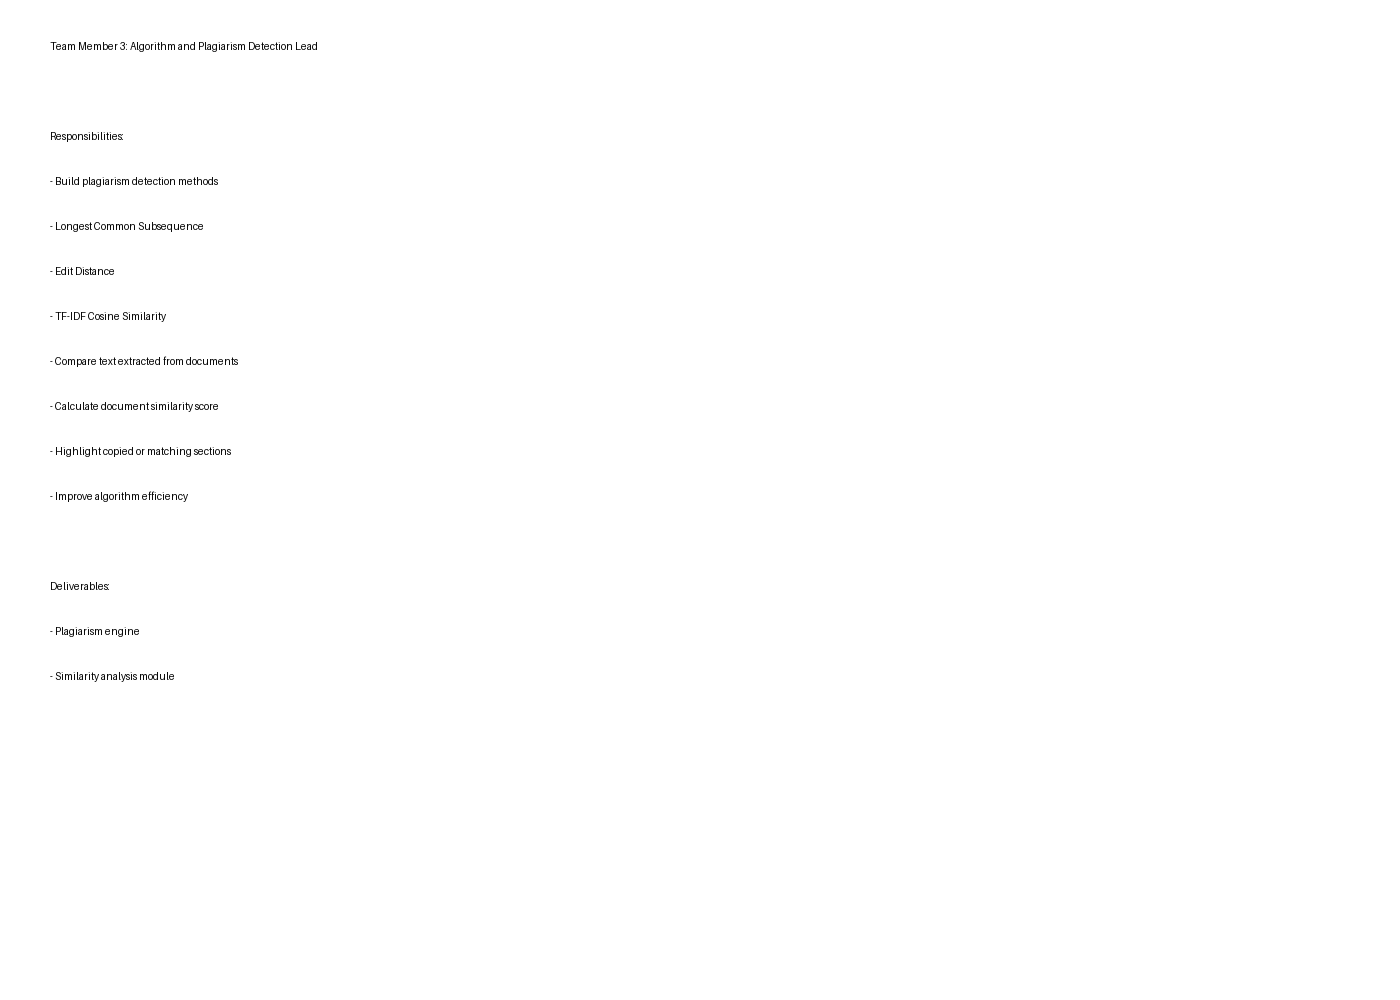

doc3.png


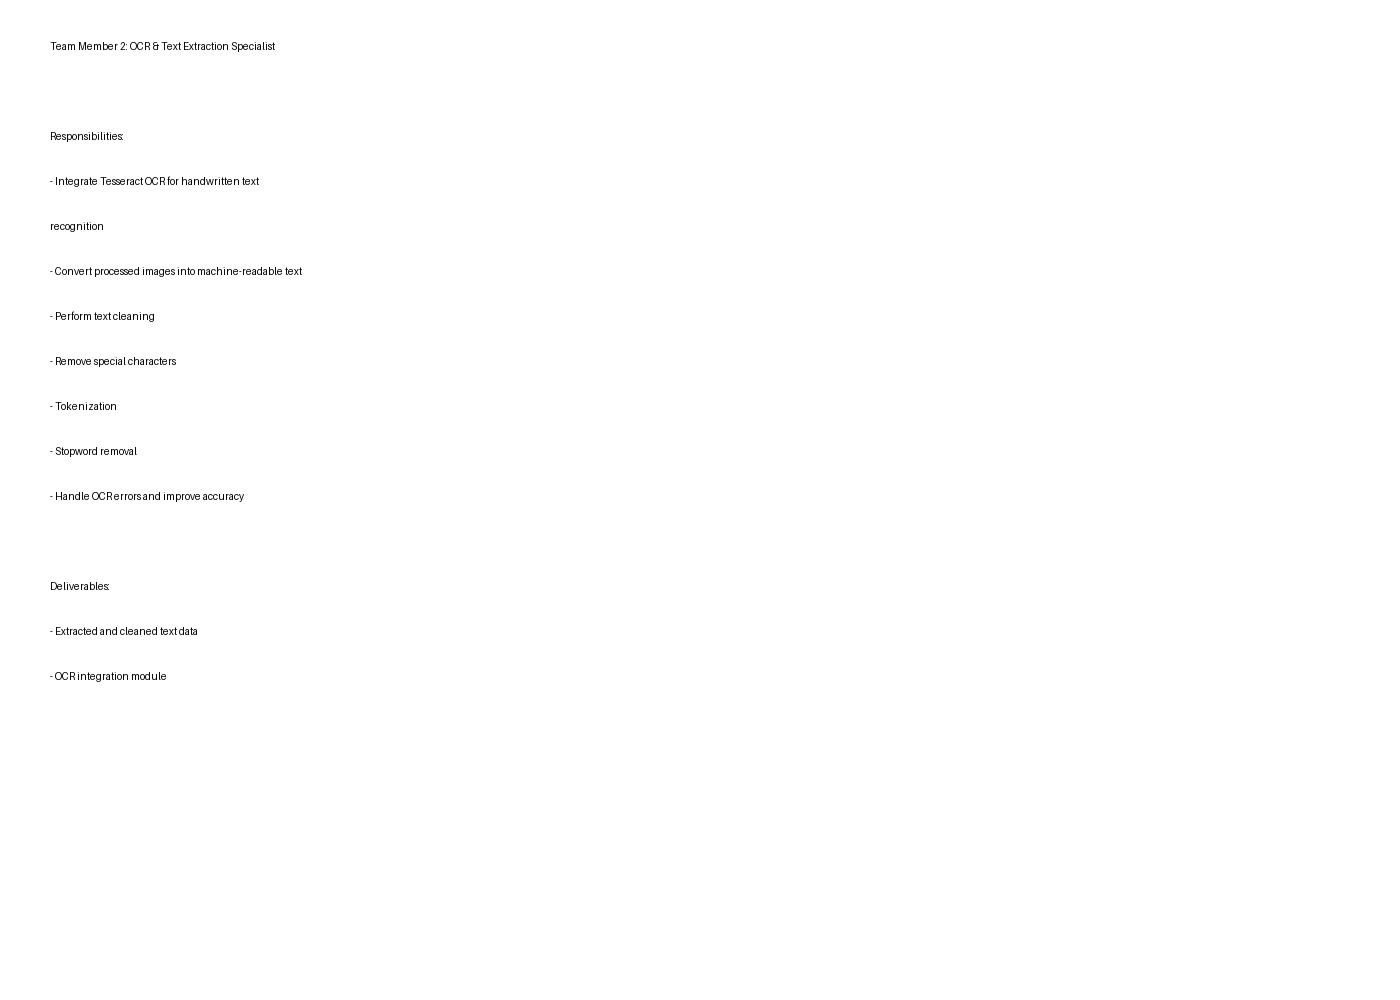

doc4.png


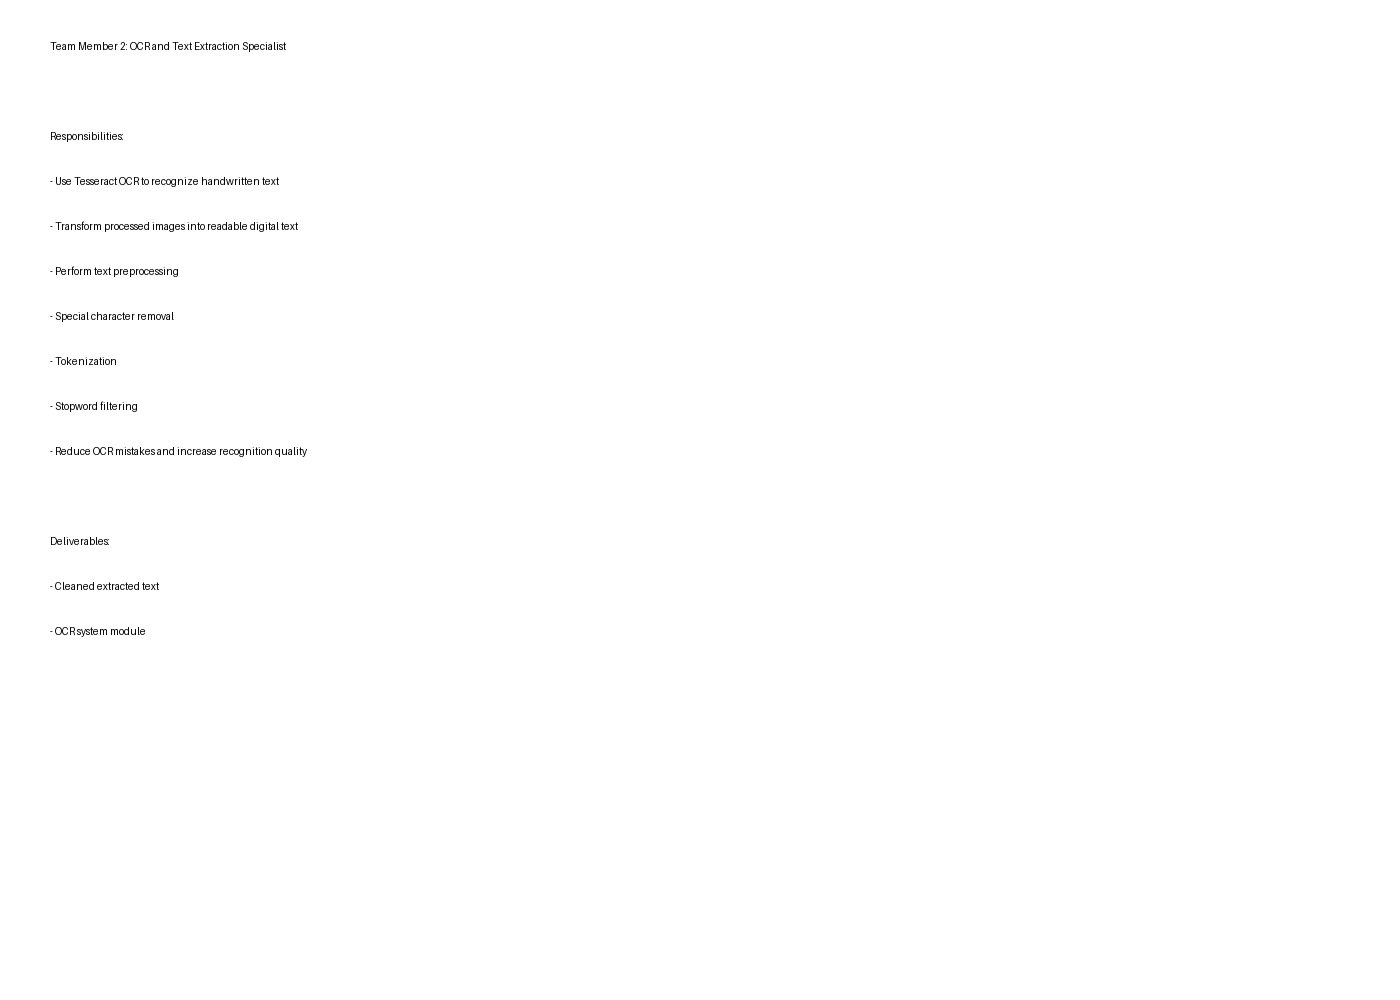

doc2.png


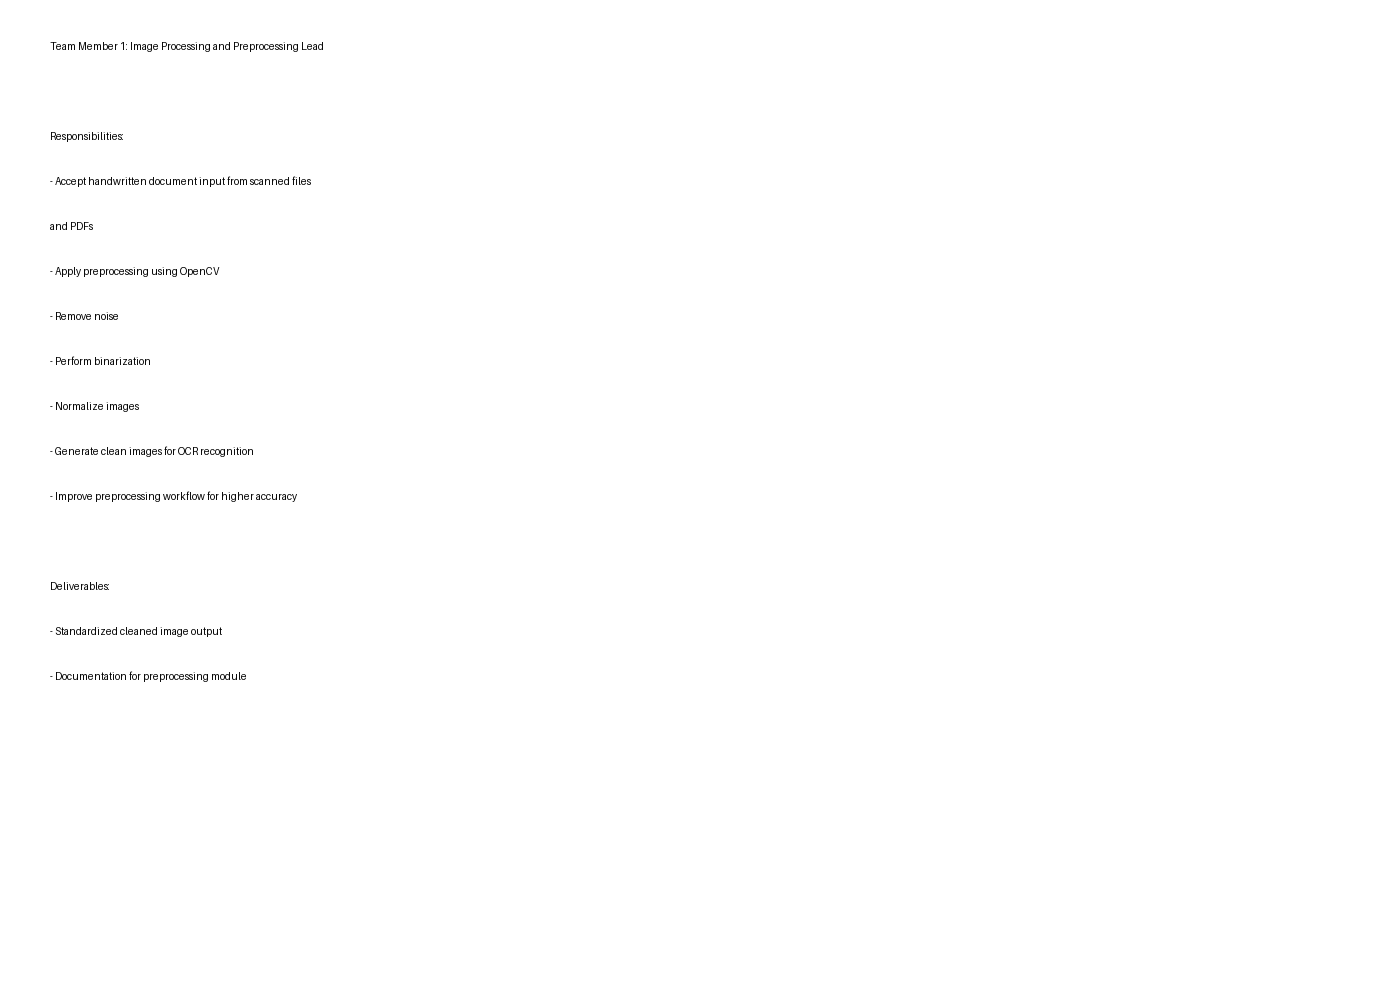

doc1.png


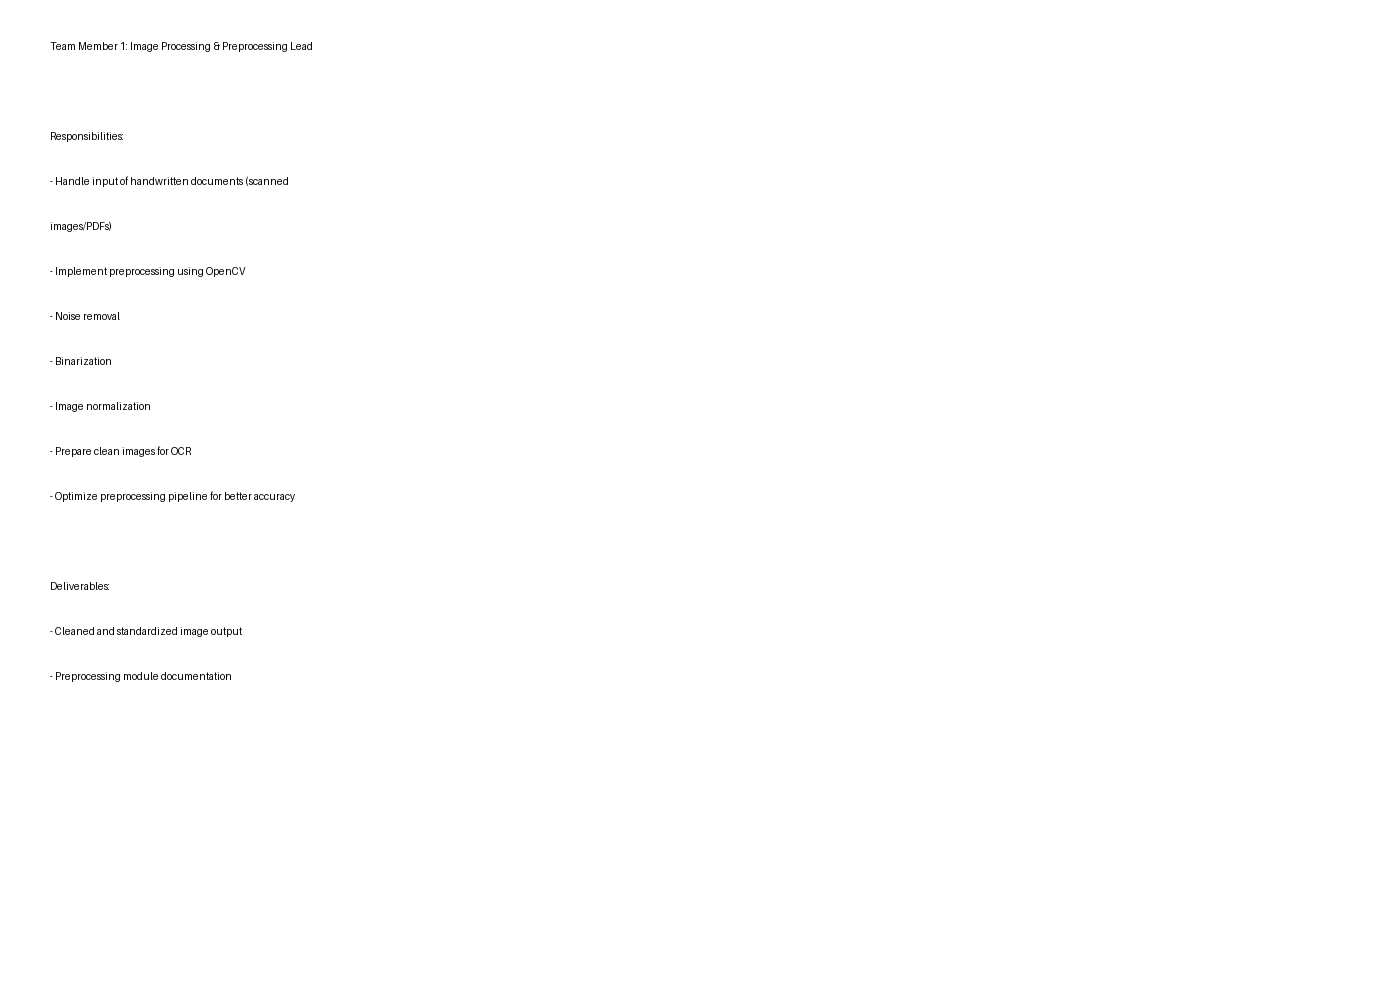

doc5.png


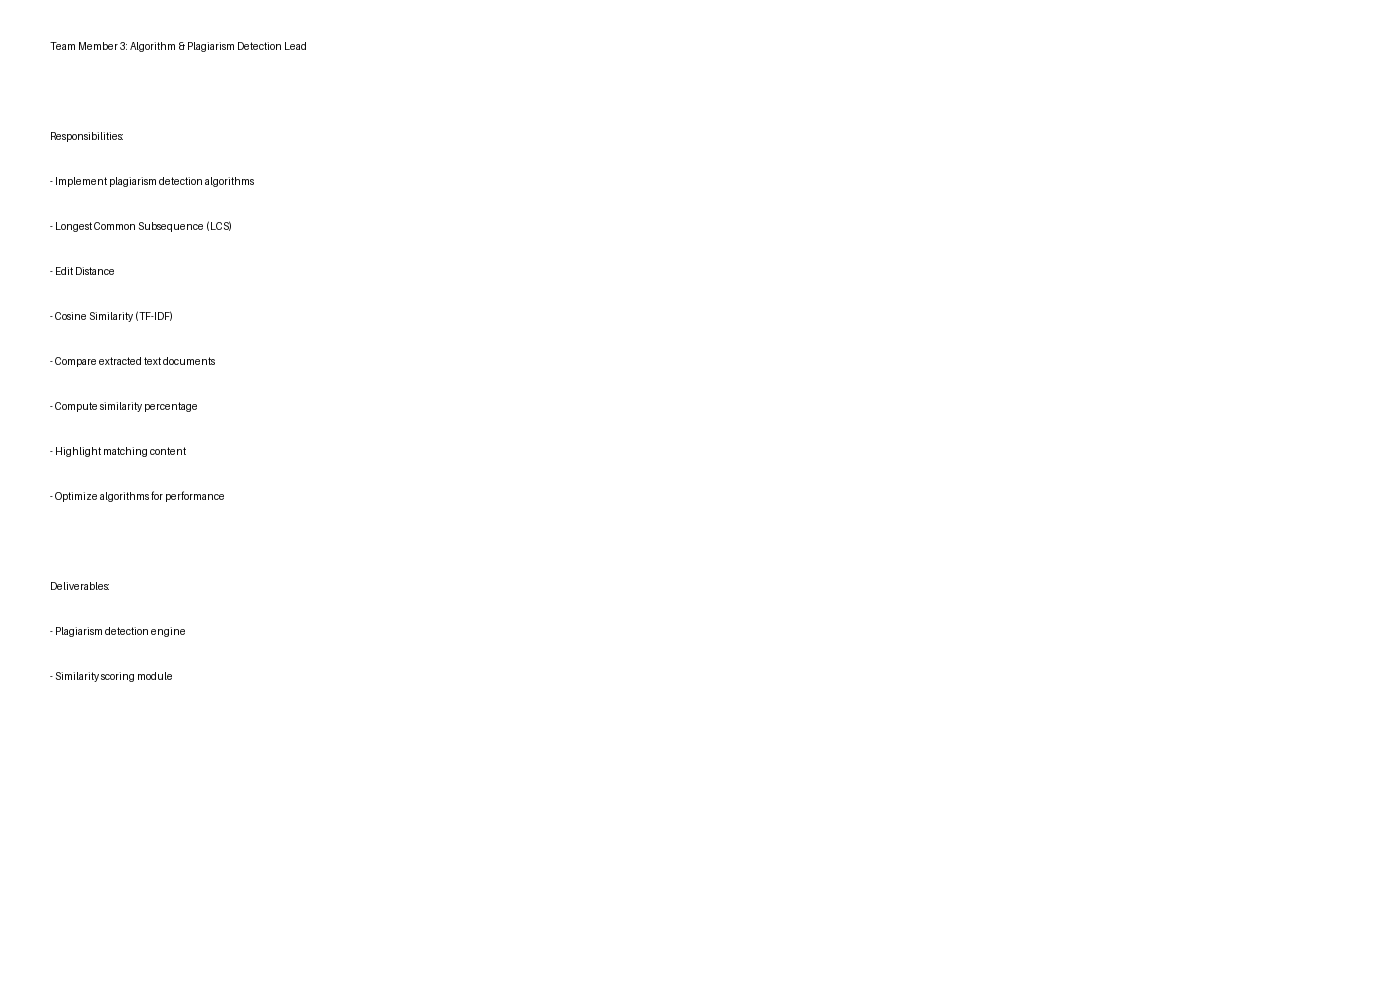

In [13]:
import os
from IPython.display import display
from PIL import Image

for file in os.listdir("/content/test_docs"):
    print(file)
    display(Image.open(f"/content/test_docs/{file}"))